
# 🛍️ E-commerce Product Recommendation System (Gemini API Edition)

This notebook loads an e-commerce dataset, analyzes it, and uses **Google Gemini API** to generate product recommendations.

> ✅ Make sure you have a [Gemini API key](https://aistudio.google.com/app/apikey). It's free and easy to generate.


In [1]:

!pip install -U pandas seaborn matplotlib google-generativeai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 43.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [3]:

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval
import google.generativeai as genai

# Paste your Gemini API key securely
from getpass import getpass
os.environ["GEMINI_API_KEY"] = getpass("Enter your Gemini API Key: ")
genai.configure(api_key=os.environ["GEMINI_API_KEY"])


Enter your Gemini API Key: ··········


In [4]:


filename = "/content/flipkart_com-ecommerce_sample.csv"
df = pd.read_csv(filename)
df.head()


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [5]:

def extract_primary_category(product_category_tree):
    try:
        return literal_eval(product_category_tree)[0].split('>>')[0].strip()
    except (ValueError, SyntaxError, IndexError):
        return None

def extract_primary_image(image_str):
    try:
        images = literal_eval(image_str)
        if images and isinstance(images, list):
            return images[0]
    except (ValueError, SyntaxError):
        return None

def determine_gender(product_name, description):
    keywords_women = ['women', 'woman', 'female', 'girls', 'girl', 'ladies', 'lady']
    keywords_men = ['men', 'man', 'male', 'boys', 'boy', 'gentlemen', 'gentleman']
    name_desc = f"{str(product_name).lower()} {str(description).lower()}"
    if any(keyword in name_desc for keyword in keywords_women):
        return 'Women'
    elif any(keyword in name_desc for keyword in keywords_men):
        return 'Men'
    else:
        return 'Unisex'

def preprocess_data(df):
    df['primary_category'] = df['product_category_tree'].apply(extract_primary_category)
    df['primary_image_link'] = df['image'].apply(extract_primary_image)
    df['gender'] = df.apply(lambda x: determine_gender(x['product_name'], x['description']), axis=1)

    columns = ['pid', 'product_url', 'product_name', 'primary_category',
               'retail_price', 'discounted_price', 'primary_image_link',
               'description', 'brand', 'gender']
    refined_df = df[columns]
    return refined_df.dropna(subset=['primary_category', 'retail_price', 'discounted_price'])


In [6]:

refined_df = preprocess_data(df)
refined_df.head()


,pid,product_url,product_name,primary_category,retail_price,discounted_price,primary_image_link,description,brand,gender
0,SRTEH2FF9KEDEFGF,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,Clothing,999.0,379.0,http://img5a.flixcart.com/image/short/u/4/a/al...,Key Features of Alisha Solid Women's Cycling S...,Alisha,Women
1,SBEEH3QGU7MFYJFY,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,Furniture,32157.0,22646.0,http://img6a.flixcart.com/image/sofa-bed/j/f/y...,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,FabHomeDecor,Men
2,SHOEH4GRSUBJGZXE,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,Footwear,999.0,499.0,http://img5a.flixcart.com/image/shoe/7/z/z/red...,Key Features of AW Bellies Sandals Wedges Heel...,AW,Women
3,SRTEH2F6HUZMQ6SJ,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,Clothing,699.0,267.0,http://img5a.flixcart.com/image/short/6/2/h/al...,Key Features of Alisha Solid Women's Cycling S...,Alisha,Women
4,PSOEH3ZYDMSYARJ5,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,Pet Supplies,220.0,210.0,http://img5a.flixcart.com/image/pet-shampoo/r/...,Specifications of Sicons All Purpose Arnica Do...,Sicons,Unisex


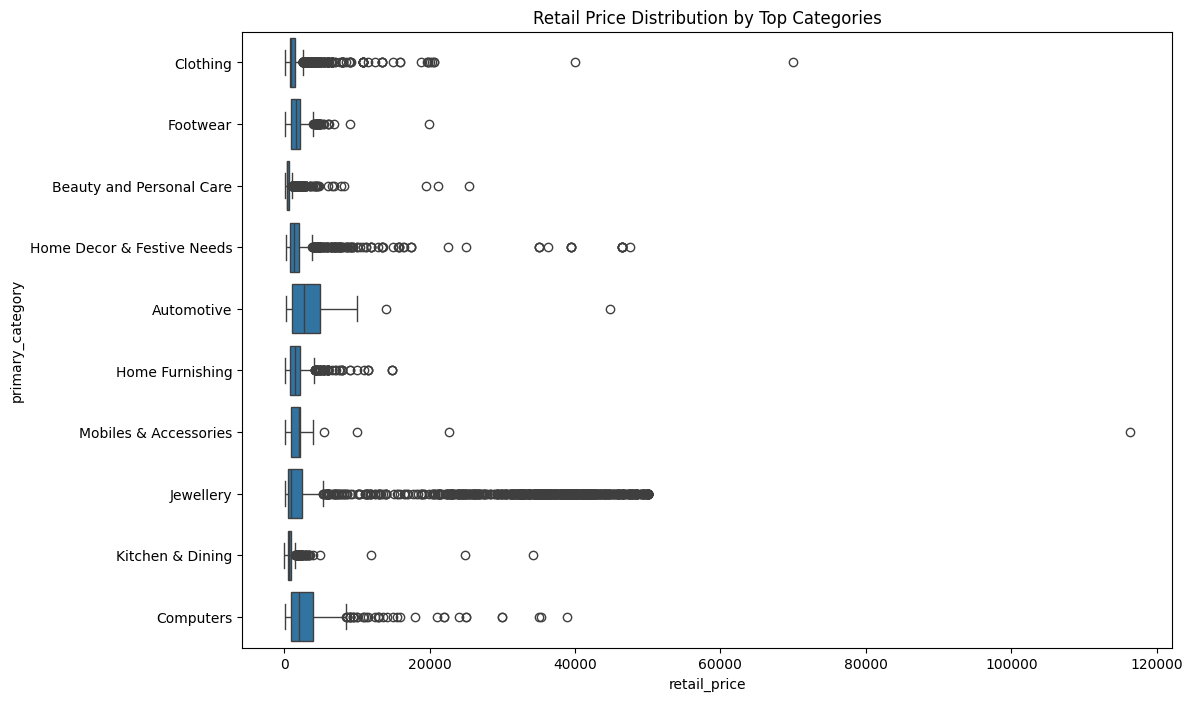

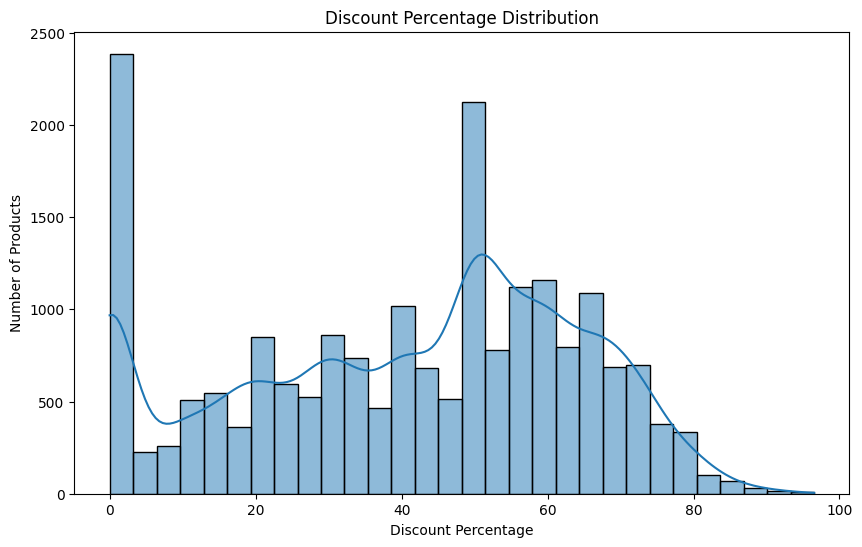

In [7]:

plt.figure(figsize=(12, 8))
top_categories = refined_df['primary_category'].value_counts().nlargest(10).index
sns.boxplot(data=refined_df[refined_df['primary_category'].isin(top_categories)],
            x='retail_price', y='primary_category')
plt.title('Retail Price Distribution by Top Categories')
plt.show()

refined_df['discount_percentage'] = ((refined_df['retail_price'] - refined_df['discounted_price']) / refined_df['retail_price']) * 100
plt.figure(figsize=(10, 6))
sns.histplot(refined_df['discount_percentage'], bins=30, kde=True)
plt.title('Discount Percentage Distribution')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Products')
plt.show()


In [8]:

model = genai.GenerativeModel("gemini-1.5-flash")

department = "Footwear"
category = "Shoes"
brand = "Nike"
price = "3000"

prompt = f"""
You are a product recommendation expert.

Please suggest three similar products based on the following details:

- Product Department: {department}
- Product Category: {category}
- Brand: {brand}
- Maximum Price Range: ₹{price}

For each recommended product, include:
- Product Name
- Product Category
- Price
- Brand
- Stock Quantity (assume a value if unknown)
- One line description

Sort the recommendations by price (lowest first).
"""

response = model.generate_content(prompt)
print(response.text)


Based on the provided information, finding exact Nike shoe models within a ₹3000 budget and knowing precise stock quantities requires real-time access to inventory databases which I do not have.  Therefore, the following are *examples* of similar Nike shoes likely to fall within the budget, with estimated pricing and stock.  Actual pricing and availability will vary by retailer and region.


**Recommendation 1:**

* **Product Name:** Nike Revolution 6
* **Product Category:** Running Shoes
* **Price:** ₹2500
* **Brand:** Nike
* **Stock Quantity:** 50
* **One line description:** Comfortable and versatile running shoes suitable for everyday use and light training.


**Recommendation 2:**

* **Product Name:** Nike Court Vision Low
* **Product Category:** Casual Shoes
* **Price:** ₹2800
* **Brand:** Nike
* **Stock Quantity:** 30
* **One line description:** Stylish and affordable low-top sneakers perfect for casual wear and everyday activities.


**Recommendation 3:**

* **Product Name:** Ni